In [ ]:
!pip install -q easyocr pandas pillow matplotlib opencv-python

In [ ]:
import easyocr
import pandas as pd
import os
import time
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
!rm -rf /content/medical-document-ocr-extraction
!git clone https://github.com/tarekmahfoudi/medical-document-ocr-extraction.git

Cloning into 'medical-document-ocr-extraction'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 103 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 6.24 MiB | 13.29 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [ ]:
project_path = "/content/medical-document-ocr-extraction"

raw_path = os.path.join(project_path, "data", "raw", "sample")
results_path = os.path.join(project_path, "results")

os.makedirs(results_path, exist_ok=True)

image_files = [
    f for f in os.listdir(raw_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of images:", len(image_files))
print(image_files[:5])

Number of images: 20
['med_doc_discharge_summary_200430_noisy.jpg', 'med_doc_discharge_summary_200436_noisy.jpg', 'med_doc_discharge_summary_200432_noisy.jpg', 'med_doc_discharge_summary_200435_noisy.jpg', 'med_doc_bill_100401_noisy.jpg']


In [ ]:
reader = easyocr.Reader(["en"], gpu=True)

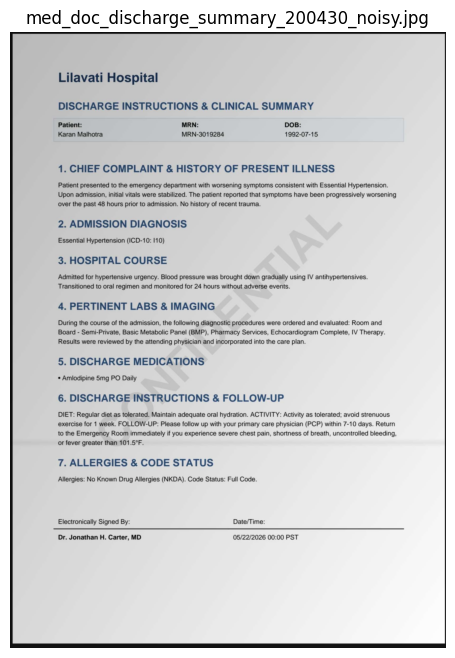

In [ ]:
filename = image_files[0]
image_path = os.path.join(raw_path, filename)

img = Image.open(image_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title(filename)
plt.show()

In [ ]:
result = reader.readtext(image_path, detail=0)

text = " ".join(result)

print(text[:2000])

Lilavati Hospital DISCHARGE INSTRUCTIONS & CLINICAL SUMMARY Patient: MRN: DOB: Karan Malhotra MRN-3019284 1992-07-15 1. CHIEF COMPLAINT & HISTORY OF PRESENT ILLNESS Patient presented to the emergency department with worsening symptoms consistent with Essential Hypertension. Upon admission , initial vitals were stabilized: The patient reported that symptoms have been progressively worsening over the past 48 hours prior to admission. No history of recent trauma. 2. ADMISSION DIAGNOSIS Essential Hypertension (ICD-10: I10) 3. HOSPITAL COURSE Admitted for hypertensive urgency. Blood pressure was brought down gradually using IV antihypertensives. Transitioned t0 oral regimen and monitored for 24 hours without adverse events: 4.PERTINENT LABS & IMAGING the course of the admission, the following diagnostic procedures were ordered and evaluated: Room and Board Semi-Private, Basic Metabolic Panel (BMP) , Pharmacy Services, Echocardiogram Complete, IV Therapy_ Results were reviewed by the attendi

In [ ]:
easyocr_results = []

for filename in image_files:
    image_path = os.path.join(raw_path, filename)

    start_time = time.time()

    result = reader.readtext(image_path, detail=0)
    text = " ".join(result)

    duration = time.time() - start_time

    easyocr_results.append({
        "filename": filename,
        "engine": "easyocr",
        "image_type": "raw",
        "ocr_text": text,
        "processing_time_seconds": duration
    })

df_easyocr = pd.DataFrame(easyocr_results)

df_easyocr.head()

,filename,engine,image_type,ocr_text,processing_time_seconds
0,med_doc_discharge_summary_200430_noisy.jpg,easyocr,raw,Lilavati Hospital DISCHARGE INSTRUCTIONS & CLI...,2.826647
1,med_doc_discharge_summary_200436_noisy.jpg,easyocr,raw,Lilavati Hospital DISCHARGE INSTRUCTIONS & CLI...,2.752742
2,med_doc_discharge_summary_200432_noisy.jpg,easyocr,raw,Manipal Hospital DISCHARGE INSTRUCTIONS & CLIN...,3.001010
3,med_doc_discharge_summary_200435_noisy.jpg,easyocr,raw,Apollo Health DISCHARGE INSTRUCTIONS & CLINICA...,2.757818
4,med_doc_bill_100401_noisy.jpg,easyocr,raw,"Apollo Health Jubilee Hills, Hyderabad, Telang...",1.844649


In [ ]:
easyocr_csv = os.path.join(results_path, "ocr_easyocr_raw.csv")

df_easyocr.to_csv(easyocr_csv, index=False)

print("Saved to:", easyocr_csv)

Saved to: /content/medical-document-ocr-extraction/results/ocr_easyocr_raw.csv


In [ ]:
pd.read_csv(easyocr_csv).head()

,filename,engine,image_type,ocr_text,processing_time_seconds
0,med_doc_discharge_summary_200430_noisy.jpg,easyocr,raw,Lilavati Hospital DISCHARGE INSTRUCTIONS & CLI...,2.826647
1,med_doc_discharge_summary_200436_noisy.jpg,easyocr,raw,Lilavati Hospital DISCHARGE INSTRUCTIONS & CLI...,2.752742
2,med_doc_discharge_summary_200432_noisy.jpg,easyocr,raw,Manipal Hospital DISCHARGE INSTRUCTIONS & CLIN...,3.001010
3,med_doc_discharge_summary_200435_noisy.jpg,easyocr,raw,Apollo Health DISCHARGE INSTRUCTIONS & CLINICA...,2.757818
4,med_doc_bill_100401_noisy.jpg,easyocr,raw,"Apollo Health Jubilee Hills, Hyderabad, Telang...",1.844649


In [ ]:
for i in range(3):
    print("=" * 80)
    print("FILE:", df_easyocr.loc[i, "filename"])
    print("=" * 80)
    print(df_easyocr.loc[i, "ocr_text"][:1500])
    print("\n")

FILE: med_doc_discharge_summary_200430_noisy.jpg
Lilavati Hospital DISCHARGE INSTRUCTIONS & CLINICAL SUMMARY Patient: MRN: DOB: Karan Malhotra MRN-3019284 1992-07-15 1. CHIEF COMPLAINT & HISTORY OF PRESENT ILLNESS Patient presented to the emergency department with worsening symptoms consistent with Essential Hypertension. Upon admission , initial vitals were stabilized: The patient reported that symptoms have been progressively worsening over the past 48 hours prior to admission. No history of recent trauma. 2. ADMISSION DIAGNOSIS Essential Hypertension (ICD-10: I10) 3. HOSPITAL COURSE Admitted for hypertensive urgency. Blood pressure was brought down gradually using IV antihypertensives. Transitioned t0 oral regimen and monitored for 24 hours without adverse events: 4.PERTINENT LABS & IMAGING the course of the admission, the following diagnostic procedures were ordered and evaluated: Room and Board Semi-Private, Basic Metabolic Panel (BMP) , Pharmacy Services, Echocardiogram Complete,

In [ ]:
tesseract_csv = os.path.join(results_path, "ocr_tesseract_raw.csv")

df_tesseract = pd.read_csv(tesseract_csv)

df_comparison = pd.concat([df_tesseract, df_easyocr], ignore_index=True)

df_comparison.head()

,filename,engine,image_type,ocr_text,processing_time_seconds
0,med_doc_bill_100401_noisy.jpg,tesseract,raw,"Apollo Health City\n\nJubilee Hills, Hyderabad...",3.066538
1,med_doc_discharge_summary_200434_noisy.jpg,tesseract,raw,Christian Medical College (CMC)\n\nDISCHARGE I...,8.177579
2,med_doc_bill_100407_noisy.jpg,tesseract,raw,\n \n \n \n \n \n \n \n \n \n \n...,2.127968
3,med_doc_discharge_summary_200435_noisy.jpg,tesseract,raw,\n\nApollo Health City\n\nDISCHARGE INSTRUCTI...,8.177355
4,med_doc_discharge_summary_200436_noisy.jpg,tesseract,raw,\n\nLilavati Hospital\n\nDISCHARGE INSTRUCTIO...,6.140183


In [ ]:
#the hardware used by each OCR engine
df_comparison["device"] = "CPU"

df_comparison.loc[
    df_comparison["engine"] == "easyocr",
    "device"
] = "Tesla T4 GPU"

df_comparison.loc[
    df_comparison["engine"] == "tesseract",
    "device"
] = "CPU"

df_comparison[
    [
        "filename",
        "engine",
        "device",
        "processing_time_seconds"
    ]
].head()

,filename,engine,device,processing_time_seconds
0,med_doc_bill_100401_noisy.jpg,tesseract,CPU,3.066538
1,med_doc_discharge_summary_200434_noisy.jpg,tesseract,CPU,8.177579
2,med_doc_bill_100407_noisy.jpg,tesseract,CPU,2.127968
3,med_doc_discharge_summary_200435_noisy.jpg,tesseract,CPU,8.177355
4,med_doc_discharge_summary_200436_noisy.jpg,tesseract,CPU,6.140183


In [ ]:
comparison_csv = os.path.join(results_path, "ocr_comparison_tesseract_easyocr.csv")

df_comparison.to_csv(comparison_csv, index=False)

print("Saved to:", comparison_csv)

Saved to: /content/medical-document-ocr-extraction/results/ocr_comparison_tesseract_easyocr.csv


In [ ]:
df_comparison.groupby("engine")["processing_time_seconds"].mean()

,processing_time_seconds
engine,
easyocr,2.343193
tesseract,5.193112


In [ ]:
time_summary = (
    df_comparison
    .groupby(
        ["engine", "device"]
    )["processing_time_seconds"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

time_summary

,engine,device,mean,min,max
0,easyocr,Tesla T4 GPU,2.343193,1.629489,3.309703
1,tesseract,CPU,5.193112,2.127968,8.177579


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
time_summary_path = os.path.join(
    results_path,
    "ocr_processing_time_summary.csv"
)

time_summary.to_csv(
    time_summary_path,
    index=False
)

print("Saved to:", time_summary_path)

Saved to: /content/medical-document-ocr-extraction/results/ocr_processing_time_summary.csv


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("EasyOCR is probably running on CPU.")

GPU available: True
GPU name: Tesla T4


## OCR experiment with EasyOCR

In this notebook, I applied EasyOCR to the same noisy medical document images used with Tesseract.

The objective is to compare two OCR engines on the same sample of medical document images.

The comparison focuses on:

- extracted text quality;
- ability to read noisy documents;
- ability to handle tables and structured layouts;
- processing time.

At this stage, the comparison is exploratory and qualitative. A more formal evaluation will be performed later using extraction rules and ground truth information.

## Processing time comparison

The processing time comparison was performed using different hardware configurations:

* EasyOCR was executed using a Tesla T4 GPU.
* Tesseract was executed on CPU.

### Results

* EasyOCR mean processing time: approximately 2.33 seconds per image.
* EasyOCR processing time range: approximately 1.62 to 3.35 seconds.
* Tesseract mean processing time: approximately 5.19 seconds per image.
* Tesseract processing time range: approximately 2.13 to 8.18 seconds.

Under these experimental conditions, EasyOCR with GPU acceleration was faster than Tesseract running on CPU.

However, this is not a direct comparison of the intrinsic speed of the two OCR engines because they were executed on different hardware. OCR text quality must also be evaluated before determining which engine is more suitable for medical document processing.
